# Все в куче

Потом удалить

In [1]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
import time
from genesis.utils import timing, Progressbar
from genesis.best_points import BestNodesFull

In [2]:
area = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

In [3]:
ndl = list(G.nodes())
# start_points = [ndl[100], ndl[2000], ndl[3000]]
start_points = {ndl[100]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}

times, nearest = FirstArrivalUnitState()(env=G, points=start_points)
ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times)

(7.509977493498235, 72.38372093023256, 99.49127906976744)

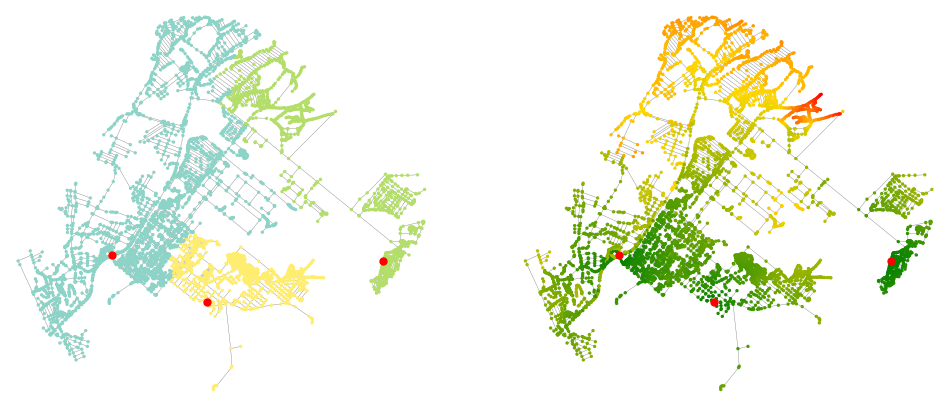

In [4]:
print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')

print('2', end='\r')
locations = start_points

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

In [5]:
# Расчет метрик для всего результата
metrics = {}
metrics['mean_arr_time'] = ArrivalTime()(times)
metrics['max_arr_time'] = ArrivalTime(np.max)(times)
metrics['median_arr_time'] = ArrivalTime(np.median)(times)

metrics['ip5'] = CoverIndex(5)(times)
metrics['ip10'] = CoverIndex()(times)
metrics['ip20'] = CoverIndex(20)(times)

print(pd.Series(metrics))

mean_arr_time       7.509977
max_arr_time       23.958373
median_arr_time     6.383067
ip5                34.992733
ip10               72.383721
ip20               99.491279
dtype: float64


In [6]:
# Расчет метрик для каждого из подразделений
for start_point in nearest.unique():
    times_part = pd.Series([t for n,t in zip(nearest, times) if n==start_point], dtype=times.dtype)
    print(start_point)
    metrics = {}
    metrics['mean_arr_time'] = np.mean(times_part)
    metrics['max_arr_time'] = np.max(times_part)
    metrics['median_arr_time'] = np.median(times_part)

    metrics['ip5'] = CoverIndex(5)(times_part)
    metrics['ip10'] = CoverIndex()(times_part)
    metrics['ip20'] = CoverIndex(20)(times_part)

    print(pd.Series(metrics))
    print(' ')

A
mean_arr_time        7.382747
max_arr_time        16.874785
median_arr_time      6.493972
ip5                 34.033486
ip10                74.155251
ip20               100.000000
dtype: float64
 
B
mean_arr_time       9.787579
max_arr_time       23.958373
median_arr_time    11.331133
ip5                24.694377
ip10               45.313773
ip20               97.718011
dtype: float64
 
C
mean_arr_time        5.114145
max_arr_time         8.456096
median_arr_time      4.963406
ip5                 50.907258
ip10               100.000000
ip20               100.000000
dtype: float64
 


Расчет только для области

In [7]:
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

times, nearest = FirstArrivalUnitState()(env=G, points=start_points, area=points_mask)

<Axes: >

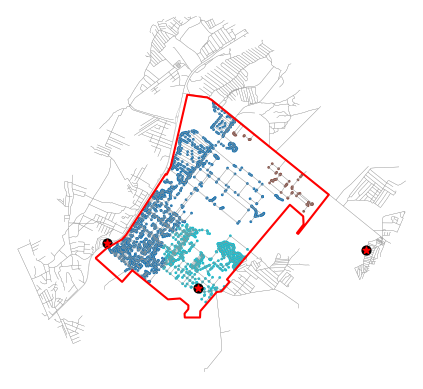

In [8]:
nodes['nearest'] = nearest

# ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_time')
ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='nearest')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
area.boundary.plot(ax=ax, color='r')
nodes.loc[locations.keys()].plot(ax=ax, markersize=40, color='k')
nodes.loc[locations.keys()].plot(ax=ax, markersize=25, color='red', marker="*")

In [9]:
FirstArrivalUnitState()(env=G, points=start_points, cutoff=5)

(1296599762    1.000000
 2042076750    1.000000
 2760591335    1.000000
 2042076753    1.012382
 2042076746    1.053790
                 ...   
 5574160013    5.997206
 2054469190    5.997553
 8089452698    5.997593
 2054469208    5.998249
 8704218601    5.999335
 Name: times, Length: 2578, dtype: float64,
 1296599762    A
 2042076750    B
 2760591335    C
 2366929606    A
 1577756011    A
              ..
 2054469139    B
 8089452699    A
 5574160013    A
 426923803     A
 8089452698    A
 Name: nearest, Length: 2578, dtype: object)

Расчет развернутым алгоритмом Дейкстры

In [10]:
def multi_source_dijkstra_reversed(G, sources, **kwargs):
    G = nx.reverse(G.copy())
    return nx.multi_source_dijkstra(G=G, sources=sources, **kwargs)

# Прямой
times, nearest = FirstArrivalUnitState()(env=G, points=start_points)
print('Прямой', ArrivalTime()(times))

# обратный расчет
times, nearest = FirstArrivalUnitState(multi_source_dijkstra_reversed)(env=G, points=start_points)
print('Обратный', ArrivalTime()(times))

Прямой 7.509977493498235
Обратный 7.3656287820942


# Тест алгоритма поиска лучшего узла полным перебором

Полный расчет в одной ячейке совсем просто

In [4]:
# Загрузка графа
G = ox.load_graphml("tests/data/test_rng.ml")

# Определение перечня узлов которые следует рассмотреть
nodes_list = list(G.nodes())[:100]

# Расчет
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
bnf(env=G, nodes_list=nodes_list)

([426923808], 8.355415617070701)

Полный расчет в одной ячейке с прогрессбаром

In [5]:
# Загрузка графа
G = ox.load_graphml("tests/data/test_rng.ml")

# Определение перечня узлов которые следует рассмотреть
nodes_list = list(G.nodes())[:100]

# Расчет
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
pb = Progressbar(len(nodes_list))
best_nodes, best_metric = bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb)
best_nodes, best_metric

|##########| 100.0%


([426923808], 8.355415617070701)

То же самое, но с ограничением по рассматриваемым узлам в пределах некоторой области

In [6]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

# Определение перечня узлов которые следует рассмотреть
nodes_list = list(G.nodes())[:100]

# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

# Расчет
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())  #, appr_val=0)
pb = Progressbar(len(nodes_list))
best_nodes, best_metric = bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb, area=points_mask)
best_nodes, best_metric

|##########| 100.0%


([426923837], 4.361576450827)

Все тоже самое, но с добавлением обертки расчета времени

In [9]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

# Определение перечня узлов которые следует рассмотреть
nodes_list = list(G.nodes())[:100]

# Расчет
bnf = timing(BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(), appr_val=0))
pb = Progressbar(len(nodes_list))
best_nodes, best_metric = bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb, area=points_mask)
best_nodes, best_metric

|##########| 100.0%
ВРЕМЯ: 5.99 сек


([426923837], 4.361576450827)

<Axes: >

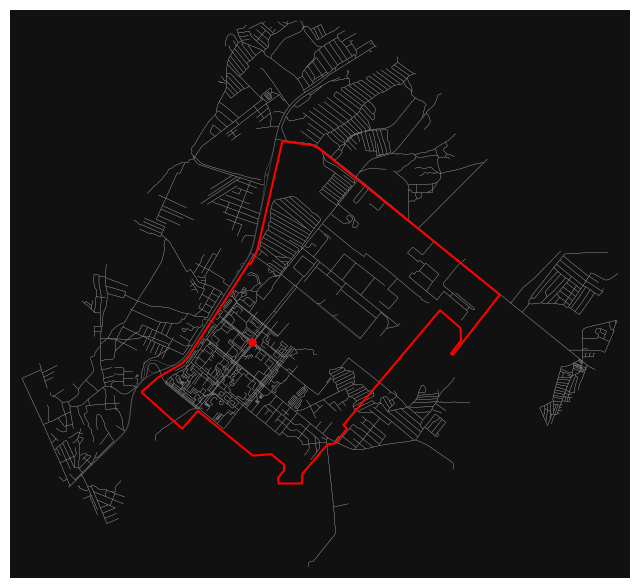

In [10]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)
# ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_times')
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[best_nodes].plot(ax=ax, markersize=25, color='red')

In [11]:
print('Тест времени расчета лучшего узла с использованием разных функций леса Вороного:')
cnt = 1000
nodes_list = list(G.nodes())[:cnt]
print('Узлов:', cnt)
print('='*80)


nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)


st = time.time()
pb = Progressbar(len(nodes_list))
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
best_node, best_metric = bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb)
ft = time.time()
print('best_node_full для оценки всех узлов:', round(ft-st,2))
print(best_node, best_metric, '\n')

st = time.time()
pb = Progressbar(len(nodes_list))
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
best_node, best_metric = bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb, area=points_mask)
ft = time.time()
print('best_node_full для оценки только узлов в области area:', round(ft-st,2))
print(best_node, best_metric, '\n')

best_node, best_metric

Тест времени расчета лучшего узла с использованием разных функций леса Вороного:
Узлов: 1000
|##########| 100.0%
best_node_full для оценки всех узлов: 58.14
[426923808] 8.355415617070701 

|##########| 100.0%
best_node_full для оценки только узлов в области area: 69.88
[1577701962] 4.328401644772975 



([1577701962], 4.328401644772975)

In [12]:
pb = Progressbar(len(nodes_list))
bnf = timing(BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max)))
bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb)

|##########| 100.0%
ВРЕМЯ: 63.97 сек


([1297036351], 18.26452771428572)

# Расчет по определению набора узлов с наилучшим значением метрики прибытия первого подразделения

In [13]:
nodes_list = list(G.nodes())
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

pb = Progressbar(len(nodes_list), bins=40)
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=CoverIndex(20))
best_nodes, best_metric = bnf(env=G, nodes_list=nodes_list, node_calc_end_function=pb)  #, area=points_mask)
len(best_nodes), best_metric

|########################################| 100.0%


(1, 100.0)

<Axes: >

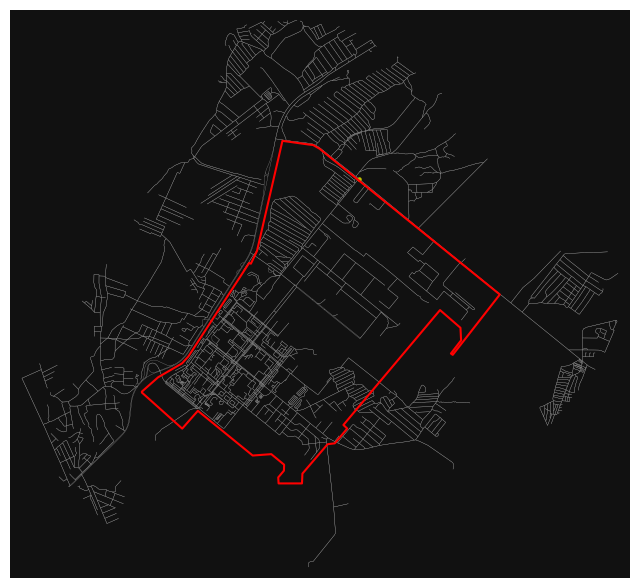

In [15]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)

fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[best_nodes].plot(ax=ax, markersize=5, color='y')

# Тест алгоритма hill climbing

In [ ]:
from genesis.best_points import BestNodesHillClimbing
# from genesis.best_points import NodeMetric
# from genesis.core import BestPoints
# from genesis.tools import get_all_neighbor_nodes

Самый общий вызов

In [ ]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

# Определение перечня узлов которые следует рассмотреть
start_node = list(G.nodes())[0]

# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

# Расчет
bnch = BestNodesHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
best_nodes, best_metric = bnch(env=G)
best_nodes, best_metric

(426923808, 8.355415617070701)

С выводом дебага маршрута поиска

ВРЕМЯ: 5.16 сек


<Axes: >

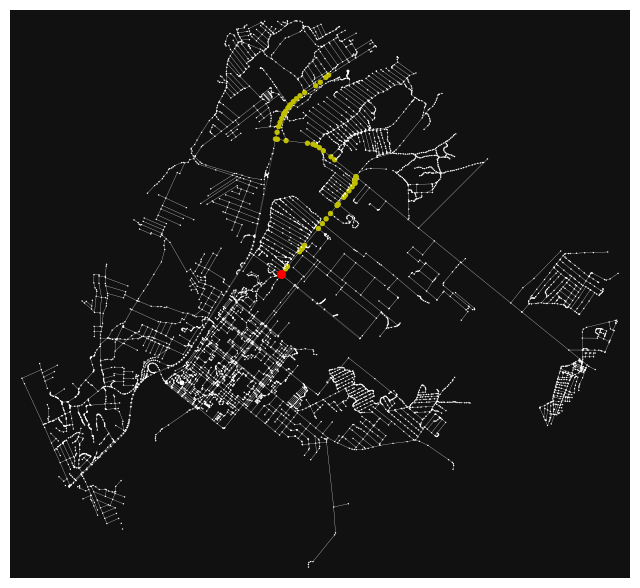

In [ ]:
bnch = timing(BestNodesHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime()))
best_nodes, best_metric, route = bnch(env=G, debug_route=True)  #, start_node=start_node)

nc = ['y' if nd in route.keys() else 'w' for nd in G.nodes()]
ns = [15 if nd in route.keys() else 1 for nd in G.nodes()]
fig, ax = ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns, show=False)
nodes.loc[[best_nodes]].plot(ax=ax, markersize=30, color='red')

Расчет от конкретного стартового узла

In [ ]:
bnch(env=G, start_node=start_node)

ВРЕМЯ: 5.4 сек


(426923808, 8.355415617070701)

Расчет с учетом только некоторых узлов

In [ ]:
bnch(env=G, area=points_mask)

ВРЕМЯ: 8.22 сек


(1577701962, 4.328401644772975)

Расчет последовательно несколькими метриками

In [ ]:
bnch_max = BestNodesHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max))
bnch_mean = BestNodesHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())

best_node, best_metric = bnch_max(env=G, area=points_mask)
print(best_node, best_metric)
best_node, best_metric = bnch_mean(env=G, start_node=best_node, area=points_mask)
print(best_node, best_metric)

2034401285 11.544648285714286
1577701962 4.328401644772975


Вызов для сравнения полного поиска по всем узлам с учетом некоторой области

In [26]:
bnf = BestNodesFull(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())

pb = Progressbar(G.number_of_nodes(), bins=50)
best_nodes, best_metric = bnf(env=G, area=points_mask, node_calc_end_function=pb)
best_nodes, best_metric

|##################################################| 100.0%


([1577701962], 4.328401644772975)

In [3]:
l1 = [1,2,3]
l2 = []

print(l1+l2)

[1, 2, 3]


# Тестирование логирования

In [1]:
import logging

In [2]:
logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

ERROR:root:An ERROR
CRITICAL:root:A message of CRITICAL severity


In [4]:
logging.basicConfig(level=logging.INFO, filename="py_log.log",filemode="w")
logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

ERROR:root:An ERROR
CRITICAL:root:A message of CRITICAL severity


# Простой граф

In [6]:
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.swiss_knife import MSF

In [8]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G


G = create_G()
start_node = list(G.nodes())[0]
times, _  = MSF(G, [start_node])

print(times)

metric = ArrivalTime()(pd.Series(times))

metric_est=25

{1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2, 12: 3, 13: 3, 14: 3, 15: 3}


In [12]:
CoverIndex(ip_val=2)(pd.Series(times))

73.33333333333333